# 📄 Credit Card Fraud Detection Using Machine Learning — Reimplementation

This notebook presents a reimplementation of the scientific paper “Credit Card Fraud Detection Using Machine Learning”. The objective is to detect fraudulent credit card transactions using machine learning techniques and compare the performance of different classification models.

The experiment uses the same Kaggle credit card fraud dataset used in the paper, which contains 284,807 transactions made by European cardholders in September 2013. The dataset is highly imbalanced, with only 492 fraudulent transactions (0.172%), making fraud detection a challenging classification problem.

### Workflow
The workflow followed in this notebook includes:
* Data loading and exploration
* Handling imbalanced transaction data
* Train–test data splitting
* Model training using:
  * Random Forest
  * AdaBoost
* Model evaluation using metrics discussed in the paper:
  * Accuracy
  * Precision
  * Recall
  * F1-score
  * Confusion Matrix
  * ROC Curve

### Extended Evaluation
In addition to the original paper metrics, extra evaluation measures such as ROC-AUC, Precision–Recall Curve, Balanced Accuracy, and Matthews Correlation Coefficient (MCC) are included to provide deeper performance analysis for imbalanced datasets.

Finally, the results of both models are compared to analyze which algorithm performs better for credit card fraud detection.

## 1. Environment Setup
First, let's bring in all the tools we need. Grouping these by purpose makes it easier to keep track of dependencies.

In [11]:
# Import the usual suspects for data manipulation and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Grab the specific machine learning models and splitting tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# We need a wide variety of metrics because standard accuracy is misleading for fraud
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, matthews_corrcoef, balanced_accuracy_score
)

# Just setting a clean style for our charts
sns.set_theme(style="whitegrid")
print("All libraries loaded and ready to go.")

All libraries loaded and ready to go.


## 2. Loading and Exploring the Data
We're using the standard Kaggle credit card dataset here. The most important thing to check right away is the class imbalance, as fraud cases are incredibly rare compared to normal transactions.

Dataset Shape: (284807, 31)

Class Distribution (0 = Normal, 1 = Fraud):
Class
0    284315
1       492
Name: count, dtype: int64


/tmp/ipython-input-232/333246752.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette="Set2")


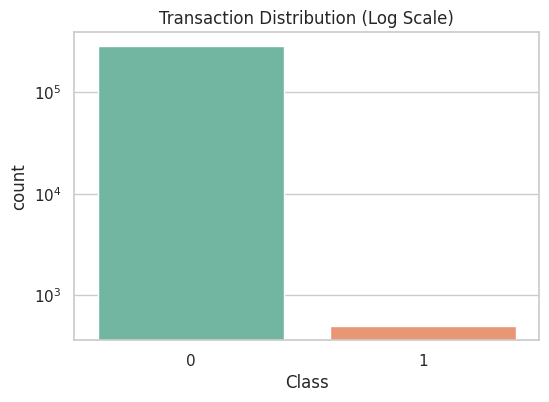

In [12]:
try:
    # Load the data - make sure the CSV is in the same folder or Colab runtime
    df = pd.read_csv("creditcard.csv")
    print(f"Dataset Shape: {df.shape}")

    # Let's see exactly how imbalanced this is
    print("\nClass Distribution (0 = Normal, 1 = Fraud):")
    print(df["Class"].value_counts())

    # Visualizing the imbalance using a log scale so the tiny fraud bar actually shows up
    plt.figure(figsize=(6, 4))
    sns.countplot(x="Class", data=df, palette="Set2")
    plt.title("Transaction Distribution (Log Scale)")
    plt.yscale("log")
    plt.show()

except FileNotFoundError:
    print("Looks like 'creditcard.csv' is missing. Please upload it to the Colab files pane first!")

## 3. Stratified Data Splitting
Because we only have a tiny fraction of fraud cases (~0.17%), a random split might accidentally put zero fraud cases in our test set. Using `stratify=y` fixes this by forcing the exact same 0.17% ratio into both the train and test sets.

In [13]:
# Separate features from the target label
X = df.drop("Class", axis=1)
y = df["Class"]

# Perform a 70/30 split, keeping the class distribution intact
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print(f"We're training on {X_train.shape[0]} samples and testing on {X_test.shape[0]}.")

We're training on 199364 samples and testing on 85443.


## 4. Training the Random Forest

Random Forest handles imbalanced data surprisingly well out of the box. We'll set `n_jobs=-1` so it uses all the CPU cores Colab gives us; otherwise, training 100 trees on 200k+ rows takes a long time.

In [14]:
print("Training the Random Forest model... give it a moment.")

# Initialize and fit the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Grab both the hard predictions (0 or 1) and the probabilities (for our ROC curves later)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest is done training.")

Training the Random Forest model... give it a moment.
Random Forest is done training.


## 5. Training AdaBoost
AdaBoost is a nice counter-point to Random Forest. Instead of building independent trees, it builds them sequentially, with each new tree trying to fix the mistakes of the previous one.

In [15]:
print("Training the AdaBoost model...")

# Initialize and fit the model
ada_model = AdaBoostClassifier(n_estimators=50, random_state=42)
ada_model.fit(X_train, y_train)

# Store predictions and probabilities
ada_pred = ada_model.predict(X_test)
ada_prob = ada_model.predict_proba(X_test)[:, 1]

print("AdaBoost is done training.")

Training the AdaBoost model...
AdaBoost is done training.


## 6. Defining a Custom Evaluation Function
If a model simply guesses "Not Fraud" for every single transaction, it gets 99.8% accuracy. That's why we need to wrap all these extra metrics (like Recall, F1, and MCC) into a single reusable function to get the true picture.

In [16]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    """Calculates and prints out a bunch of useful metrics for imbalanced datasets."""
    print(f"\n--- {model_name} Performance ---")

    # The standard scikit-learn report gives a good quick overview
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Calculate the exact numbers for our summary table
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Avg Precision": average_precision_score(y_true, y_prob)
    }

    # Print a clean summary
    print("Deep-Dive Metrics:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name:<18}: {value:.4f}")

    return metrics

# Run our predictions through the function
rf_metrics = evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
ada_metrics = evaluate_model("AdaBoost", y_test, ada_pred, ada_prob)


--- Random Forest Performance ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.96      0.76      0.85       148

    accuracy                           1.00     85443
   macro avg       0.98      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443

Deep-Dive Metrics:
  Accuracy          : 0.9995
  Precision         : 0.9573
  Recall            : 0.7568
  F1 Score          : 0.8453
  ROC AUC           : 0.9307
  Balanced Accuracy : 0.8783
  MCC               : 0.8509
  Avg Precision     : 0.8227

--- AdaBoost Performance ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.74      0.68      0.70       148

    accuracy                           1.00     85443
   macro avg       0.87      0.84      0.85     85443
weighted avg       1.00      1.00    

## 7. Plotting Confusion Matrices and Curves

Visuals are often easier to interpret than raw text. Here we'll plot the confusion matrices to see exactly how many frauds slipped through the cracks, alongside the ROC and Precision-Recall curves.

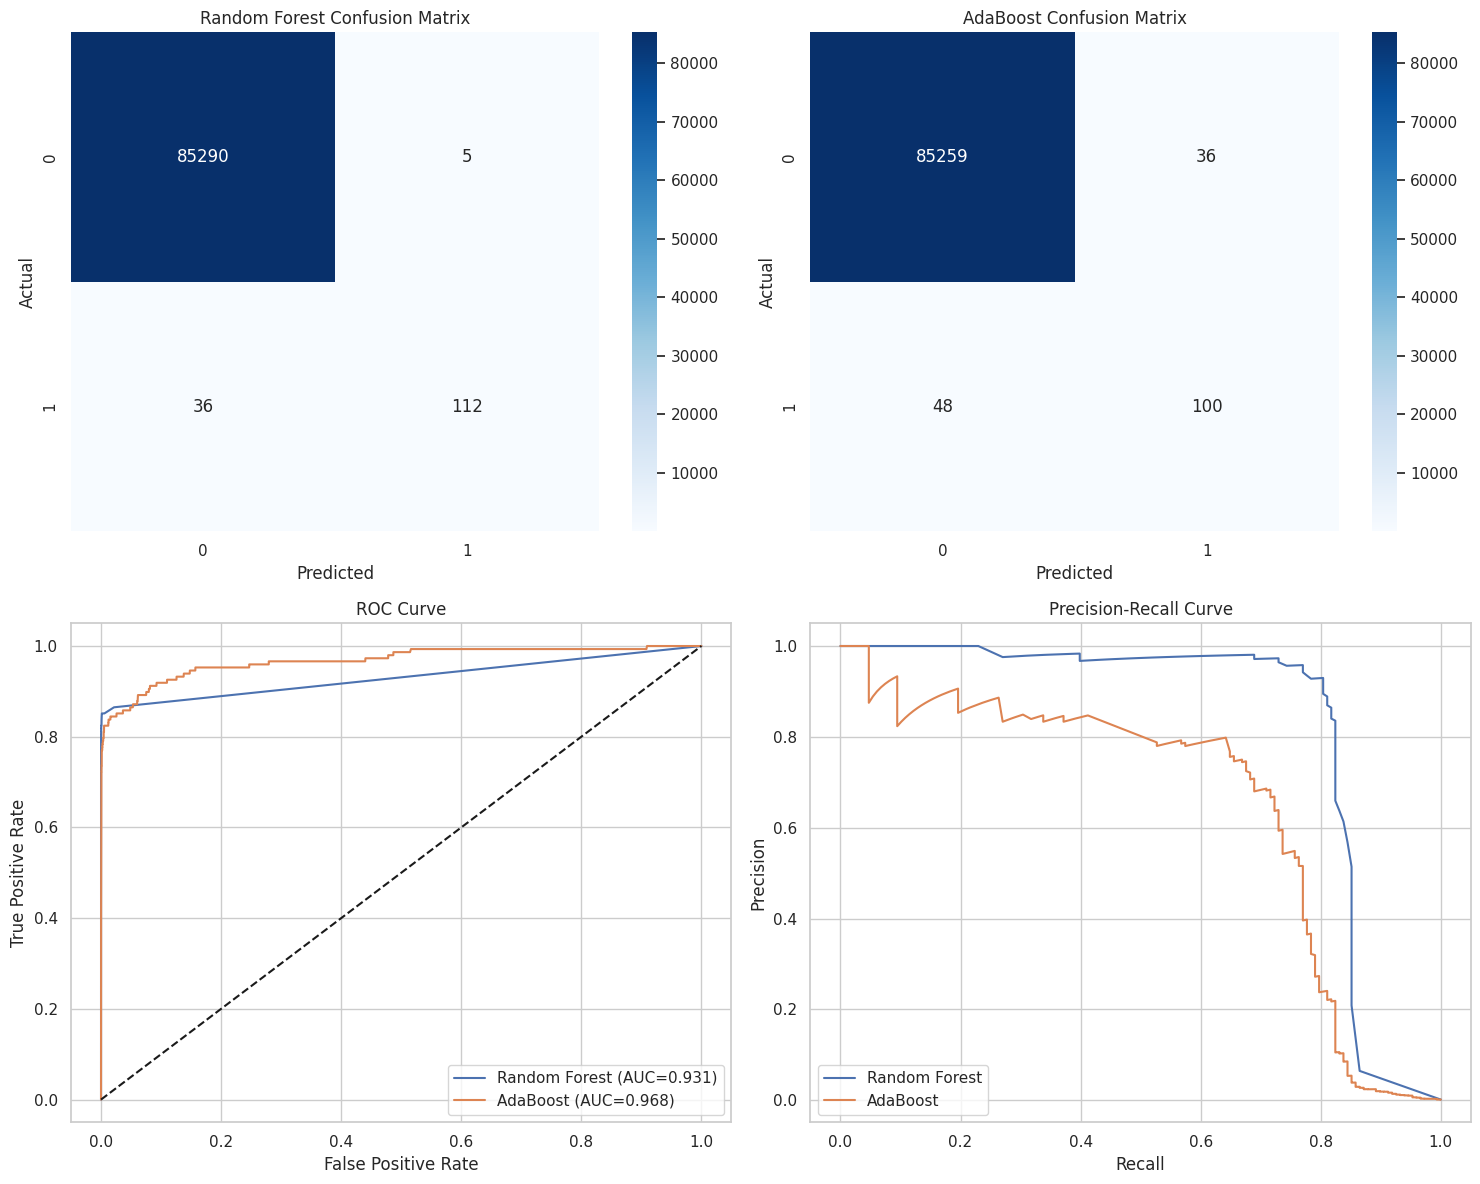

In [17]:
# Set up a 2x2 grid for all our plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0, 0])
axes[0, 0].set_title("Random Forest Confusion Matrix")
axes[0, 0].set_ylabel("Actual")
axes[0, 0].set_xlabel("Predicted")

# 2. AdaBoost Confusion Matrix
sns.heatmap(confusion_matrix(y_test, ada_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0, 1])
axes[0, 1].set_title("AdaBoost Confusion Matrix")
axes[0, 1].set_ylabel("Actual")
axes[0, 1].set_xlabel("Predicted")

# 3. ROC Curve Comparison
for name, prob in [("Random Forest", rf_prob), ("AdaBoost", ada_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[1, 0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")

axes[1, 0].plot([0,1], [0,1], 'k--')
axes[1, 0].set_title("ROC Curve")
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].legend()

# 4. Precision-Recall Curve (Usually more informative for imbalanced data)
for name, prob in [("Random Forest", rf_prob), ("AdaBoost", ada_prob)]:
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)
    axes[1, 1].plot(recall_vals, precision_vals, label=name)

axes[1, 1].set_title("Precision-Recall Curve")
axes[1, 1].set_xlabel("Recall")
axes[1, 1].set_ylabel("Precision")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 8. Feature Importance and Final Summary
It's helpful to know why the model is making its decisions. Since the Kaggle data is anonymized into variables like V1, V2, etc., this lets us see which anonymous vectors matter the most.

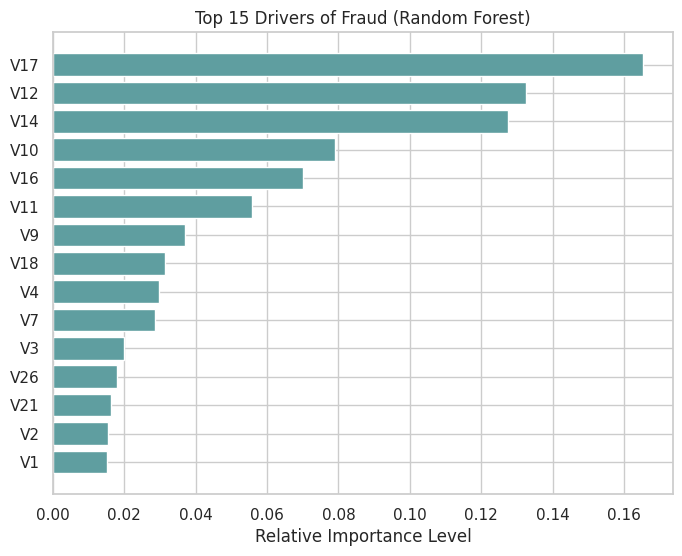


--- Final Model Showdown ---


,Metric,Random Forest,AdaBoost
0,Accuracy,0.9995,0.9990
1,Precision,0.9573,0.7353
2,Recall,0.7568,0.6757
3,F1 Score,0.8453,0.7042
4,ROC AUC,0.9307,0.9675


In [18]:
# Grab the top 15 most important features from the Random Forest
importances = rf_model.feature_importances_
top_indices = np.argsort(importances)[-15:]

plt.figure(figsize=(8, 6))
plt.barh(range(len(top_indices)), importances[top_indices], color='cadetblue')
plt.yticks(range(len(top_indices)), X.columns[top_indices])
plt.title("Top 15 Drivers of Fraud (Random Forest)")
plt.xlabel("Relative Importance Level")
plt.show()

# Build a final comparison dataframe from the metrics we calculated earlier
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Random Forest": [rf_metrics['Accuracy'], rf_metrics['Precision'], rf_metrics['Recall'], rf_metrics['F1 Score'], rf_metrics['ROC AUC']],
    "AdaBoost": [ada_metrics['Accuracy'], ada_metrics['Precision'], ada_metrics['Recall'], ada_metrics['F1 Score'], ada_metrics['ROC AUC']]
})

print("\n--- Final Model Showdown ---")
display(comparison_df.round(4))

## 9. Saving the Models
Finally, let's dump these models to disk. Random Forests take a while to train, so saving them means we can just load the `.pkl` file next time instead of re-running the `.fit()` functions if we want to deploy this.

In [19]:
import joblib
import os

# Create a folder to keep things organized
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# Save Random Forest
rf_path = 'saved_models/random_forest_fraud_model.pkl'
joblib.dump(rf_model, rf_path)
print(f"Random Forest successfully saved to {rf_path}")

# Save AdaBoost
ada_path = 'saved_models/adaboost_fraud_model.pkl'
joblib.dump(ada_model, ada_path)
print(f"AdaBoost successfully saved to {ada_path}")

print("\nTip: Don't forget to download the 'saved_models' folder to your local machine before closing Colab!")

Random Forest successfully saved to saved_models/random_forest_fraud_model.pkl
AdaBoost successfully saved to saved_models/adaboost_fraud_model.pkl

Tip: Don't forget to download the 'saved_models' folder to your local machine before closing Colab!
